
Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor




Working directory:
[1] "/home/diel/RustroverProjects/OpenMLS_containerized"

Trying to read:
[1] "benchmark_output/compose-20w-20260412-155656/events.csv"

Rows / columns:
[1] 3612   26

Operation counts:
# A tibble: 6 × 2
  op                              n
  <chr>                       <int>
1 add_commit_create              19
2 application_message_create   1524
3 application_message_receive  1524
4 remove_commit_create           18
5 update_commit_create          508
6 welcome_create_total           19

Prepared add_commit_create data:
# A tibble: 19 × 4
   member_count cpu_ms artifact_kib     n
          <dbl>  <dbl>        <dbl> <int>
 1            1  1.01         0.630     1
 2            2  0.623        0.745     1
 3            3  0.558        0.826     1
 4            4  0.649        0.859     1
 5            5  0.567        0.940     1
 6            6  0.665        0.940     1
 7            7  0.540        0.940     1
 8            8  0.634        0.974     1
 9            9 

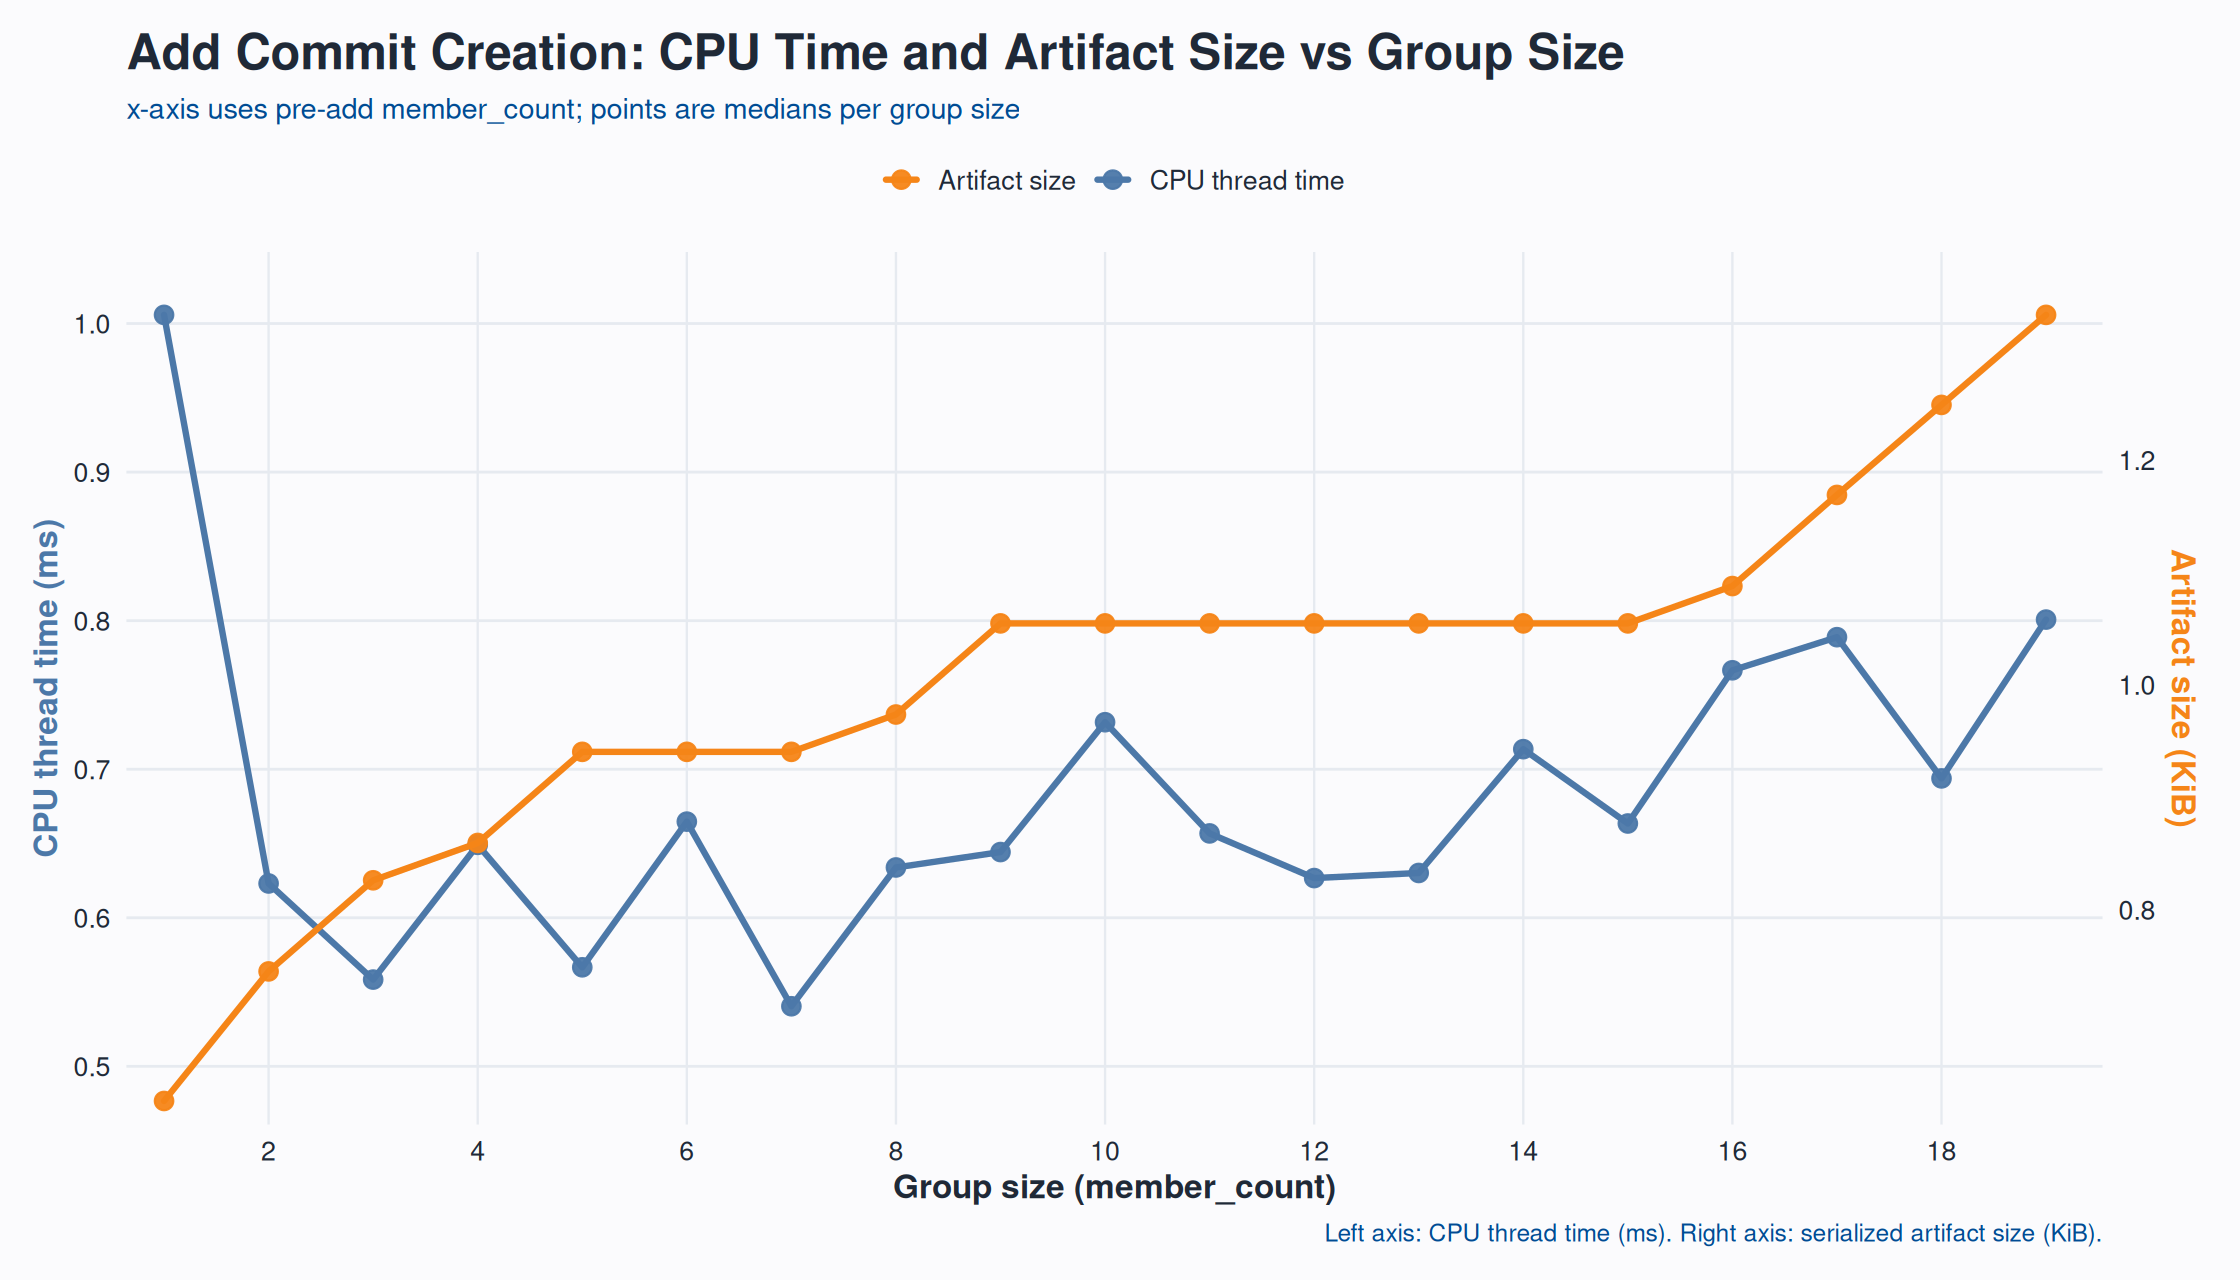

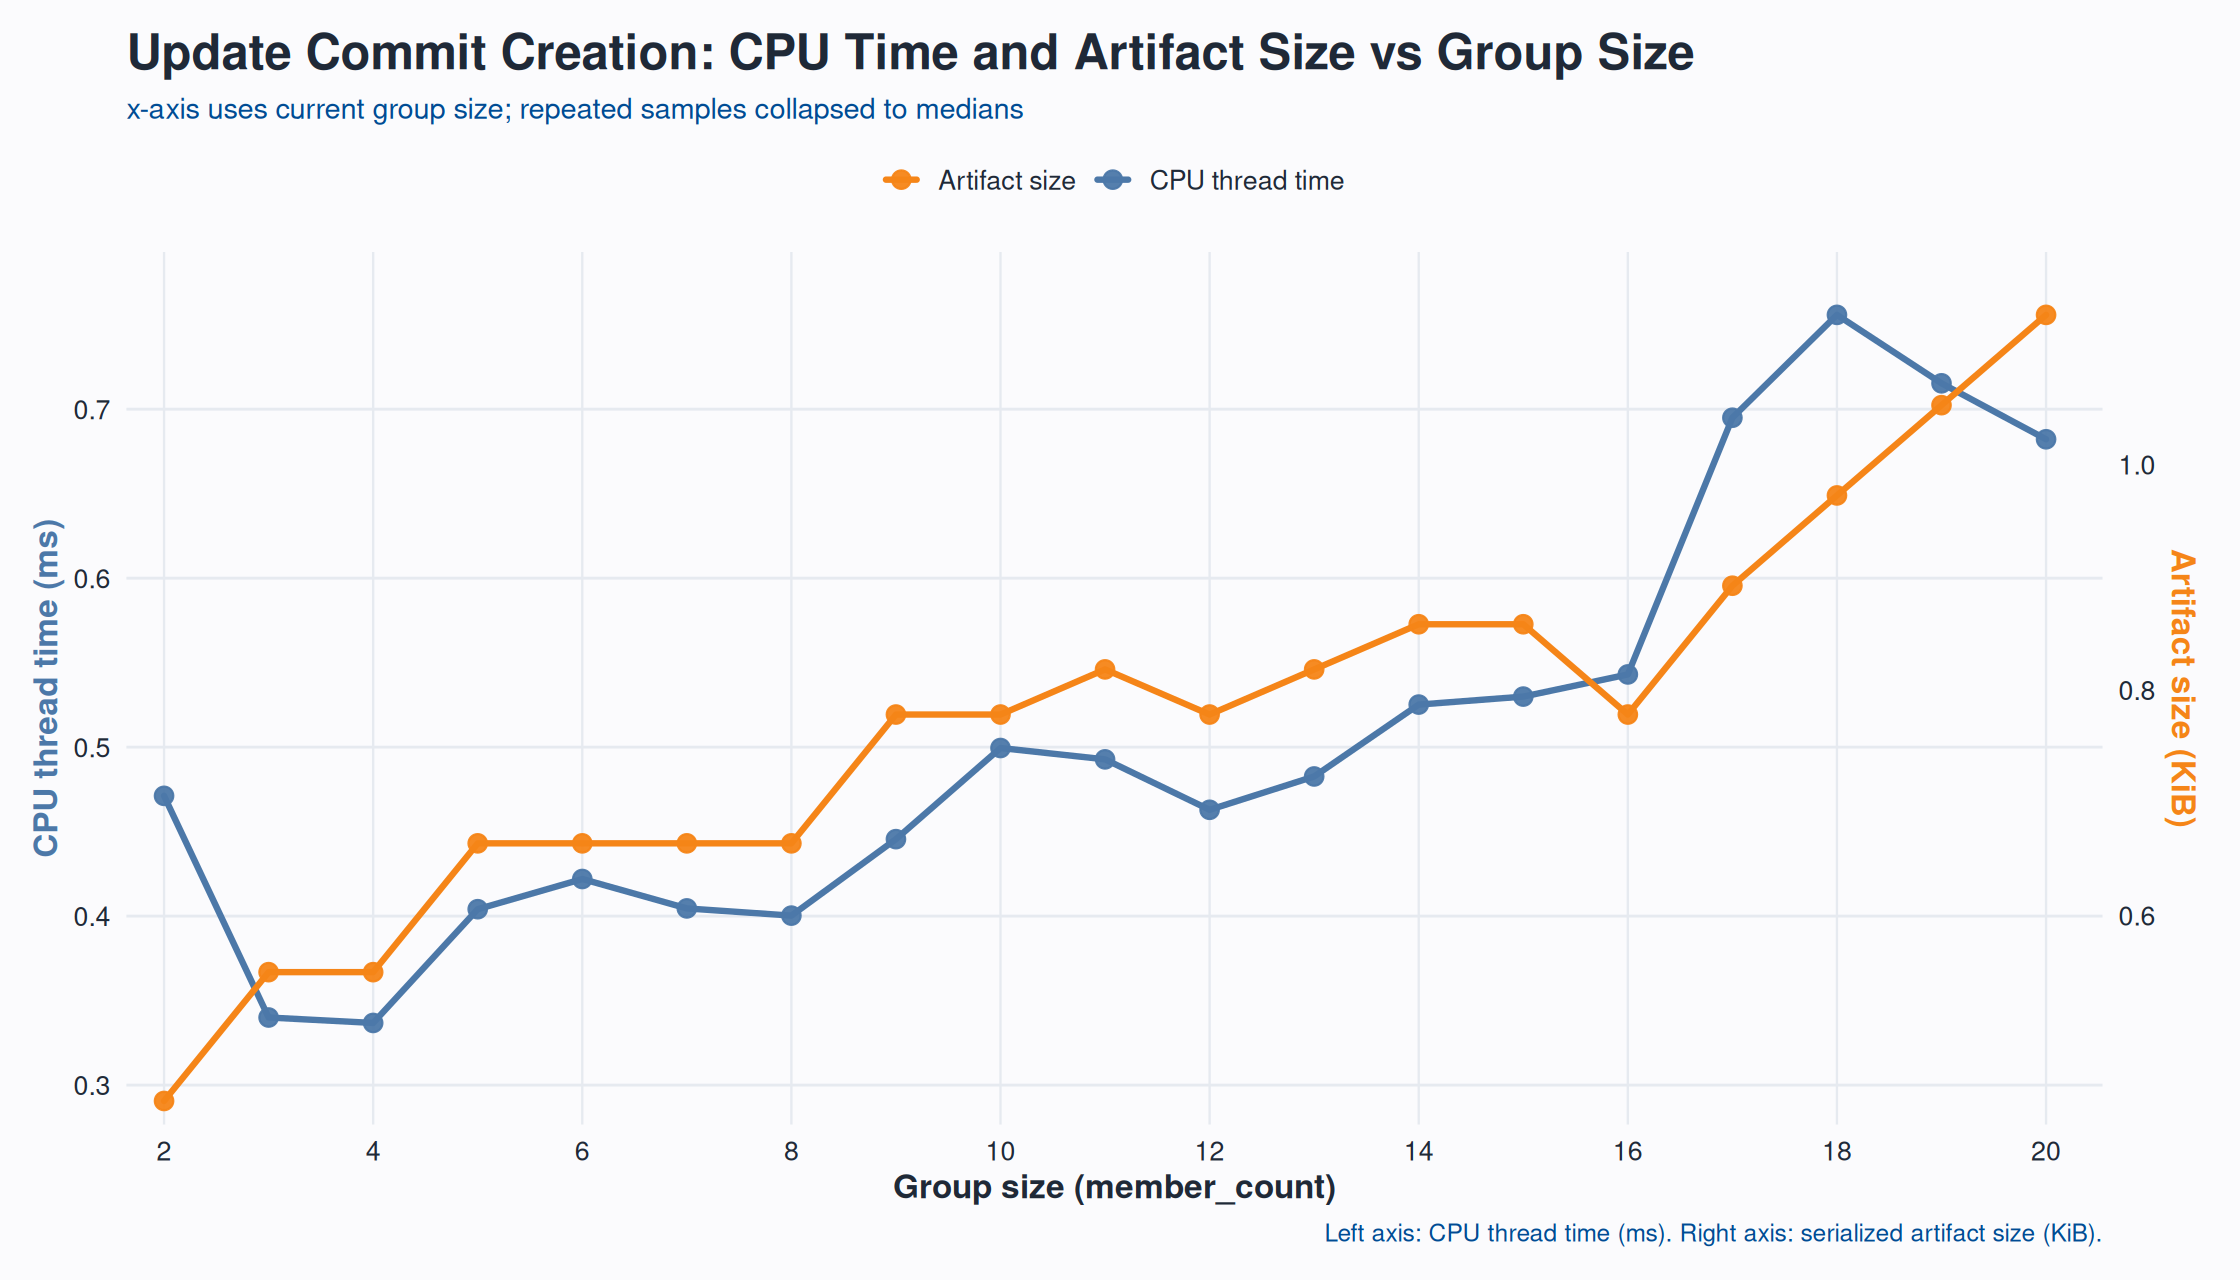

Saved plots to:
[1] "benchmark_output/compose-20w-20260412-155656/plots"


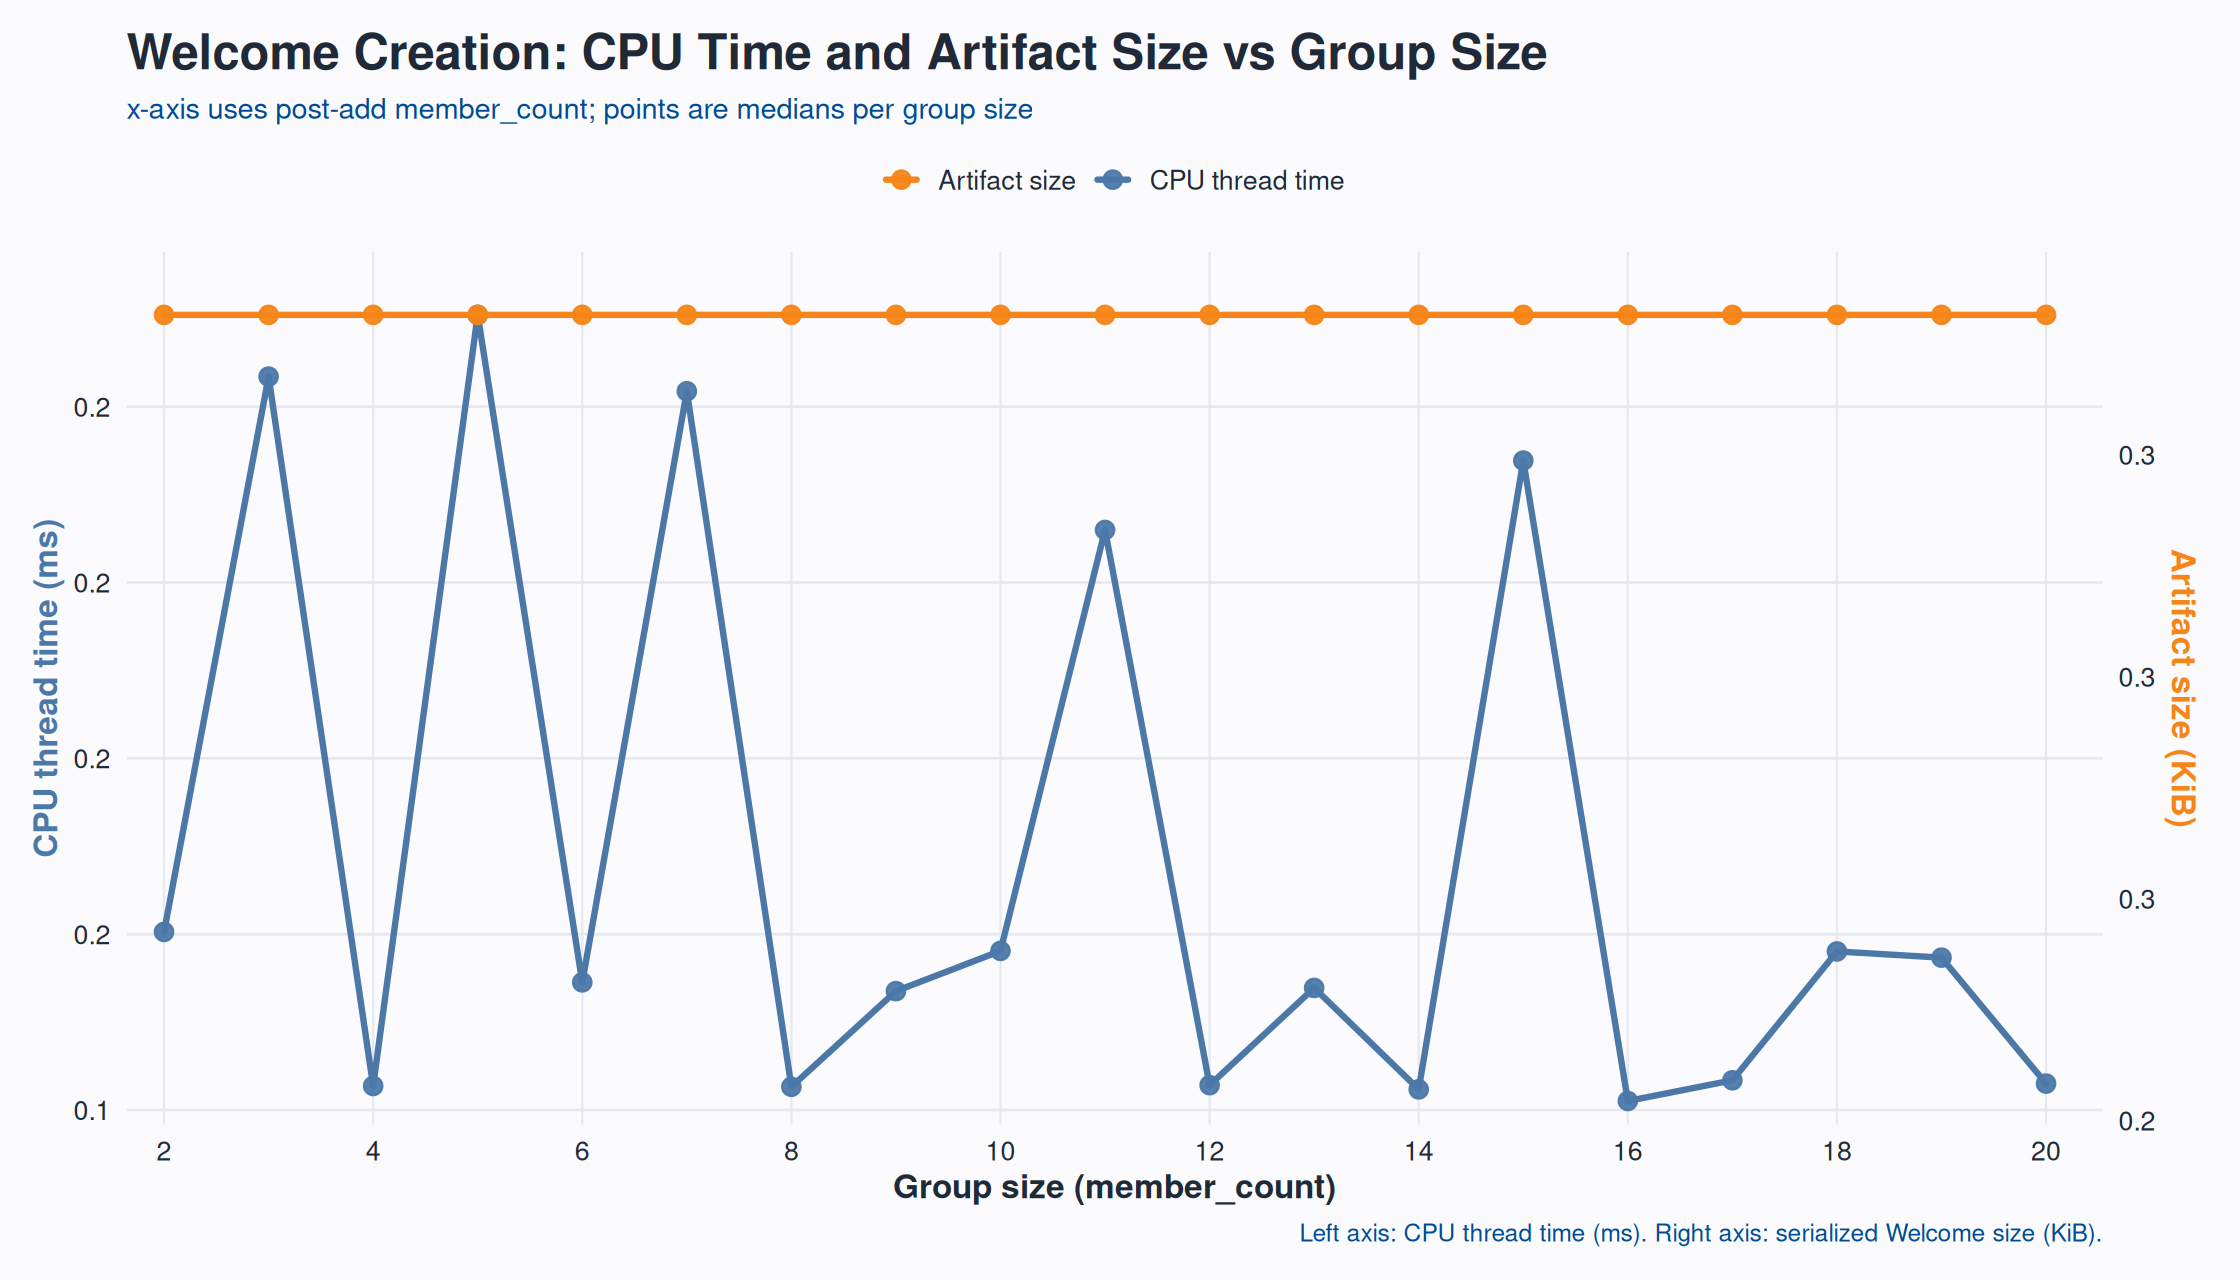

In [3]:
packages <- c("readr", "dplyr", "ggplot2", "scales")

for (p in packages) {
  if (!requireNamespace(p, quietly = TRUE)) {
    install.packages(p)
  }
}

library(readr)
library(dplyr)
library(ggplot2)
library(scales)

# Make notebook plots comfortably large on screen
if (requireNamespace("repr", quietly = TRUE)) {
  options(repr.plot.width = 14, repr.plot.height = 8, repr.plot.res = 160)
}

cat("Working directory:\n")
print(getwd())
cat("\n")

csv_path <- "benchmark_output/compose-20w-20260412-155656/events.csv"

if (!file.exists(csv_path)) {
  stop(
    paste0(
      "CSV not found at: ", csv_path, "\n",
      "Update csv_path to the correct run directory."
    )
  )
}

cat("Trying to read:\n")
print(csv_path)
cat("\n")

df <- read_csv(
  csv_path,
  show_col_types = FALSE,
  col_types = cols(
    worker_id = col_character(),
    ts_unix_ns = col_character()
  )
)

cat("Rows / columns:\n")
print(dim(df))
cat("\n")

cat("Operation counts:\n")
print(count(df, op))
cat("\n")

required_cols <- c("op", "member_count", "cpu_thread_ns", "artifact_size_bytes")
missing_cols <- setdiff(required_cols, names(df))
if (length(missing_cols) > 0) {
  stop(paste("Missing required columns:", paste(missing_cols, collapse = ", ")))
}

# ----------------------------
# Styling helpers
# ----------------------------
cpu_col <- "#4C78A8"
artifact_col <- "#F58518"
grid_col <- "#E6EAF0"
bg_col <- "#FBFBFD"
text_col <- "#1F2937"

pretty_theme <- function() {
  theme_minimal(base_size = 16) +
    theme(
      plot.background = element_rect(fill = bg_col, colour = NA),
      panel.background = element_rect(fill = bg_col, colour = NA),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_line(colour = grid_col, linewidth = 0.5),
      panel.grid.major.y = element_line(colour = grid_col, linewidth = 0.6),
      plot.title = element_text(size = 22, face = "bold", colour = text_col),
      plot.subtitle = element_text(size = 13, colour = muted(text_col)),
      plot.caption = element_text(size = 11, colour = muted(text_col)),
      axis.title.x = element_text(size = 15, face = "bold", colour = text_col),
      axis.title.y.left = element_text(size = 15, face = "bold", colour = cpu_col),
      axis.title.y.right = element_text(size = 15, face = "bold", colour = artifact_col),
      axis.text = element_text(size = 12, colour = text_col),
      legend.position = "top",
      legend.direction = "horizontal",
      legend.title = element_blank(),
      legend.text = element_text(size = 12, colour = text_col),
      plot.margin = margin(15, 20, 15, 15)
    )
}

prep_dual_axis_df <- function(data, op_name) {
  data %>%
    filter(op == op_name) %>%
    filter(!is.na(member_count), !is.na(cpu_thread_ns), !is.na(artifact_size_bytes)) %>%
    mutate(
      cpu_ms = cpu_thread_ns / 1e6,
      artifact_kib = artifact_size_bytes / 1024
    ) %>%
    group_by(member_count) %>%
    summarise(
      cpu_ms = median(cpu_ms, na.rm = TRUE),
      artifact_kib = median(artifact_kib, na.rm = TRUE),
      n = n(),
      .groups = "drop"
    ) %>%
    arrange(member_count)
}

make_dual_axis_plot <- function(plot_df, title_text, subtitle_text, caption_text) {
  if (nrow(plot_df) == 0) {
    stop(paste("No usable rows for plot:", title_text))
  }

  max_cpu <- max(plot_df$cpu_ms, na.rm = TRUE)
  max_artifact <- max(plot_df$artifact_kib, na.rm = TRUE)

  if (!is.finite(max_cpu) || !is.finite(max_artifact) || max_artifact == 0) {
    scale_factor <- 1
  } else {
    scale_factor <- max_cpu / max_artifact
  }

  ggplot(plot_df, aes(x = member_count)) +
    geom_line(
      aes(y = cpu_ms, colour = "CPU thread time"),
      linewidth = 1.35,
      lineend = "round"
    ) +
    geom_point(
      aes(y = cpu_ms, colour = "CPU thread time"),
      size = 3.4,
      alpha = 0.95
    ) +
    geom_line(
      aes(y = artifact_kib * scale_factor, colour = "Artifact size"),
      linewidth = 1.35,
      lineend = "round"
    ) +
    geom_point(
      aes(y = artifact_kib * scale_factor, colour = "Artifact size"),
      size = 3.4,
      alpha = 0.95
    ) +
    scale_colour_manual(
      values = c(
        "CPU thread time" = cpu_col,
        "Artifact size" = artifact_col
      )
    ) +
    scale_x_continuous(
      breaks = pretty_breaks(n = 12),
      expand = expansion(mult = c(0.02, 0.03))
    ) +
    scale_y_continuous(
      name = "CPU thread time (ms)",
      labels = label_number(accuracy = 0.1),
      sec.axis = sec_axis(
        ~ . / scale_factor,
        name = "Artifact size (KiB)",
        labels = label_number(accuracy = 0.1)
      ),
      expand = expansion(mult = c(0.03, 0.08))
    ) +
    labs(
      title = title_text,
      subtitle = subtitle_text,
      x = "Group size (member_count)",
      caption = caption_text
    ) +
    pretty_theme()
}

# ----------------------------
# Prepare data
# ----------------------------
add_df <- prep_dual_axis_df(df, "add_commit_create")
update_df <- prep_dual_axis_df(df, "update_commit_create")
welcome_df <- prep_dual_axis_df(df, "welcome_create_total")

cat("Prepared add_commit_create data:\n")
print(add_df)
cat("\n")

cat("Prepared update_commit_create data:\n")
print(update_df)
cat("\n")

cat("Prepared welcome_create_total data:\n")
print(welcome_df)
cat("\n")

# ----------------------------
# Build plots
# ----------------------------
p_add <- make_dual_axis_plot(
  add_df,
  title_text = "Add Commit Creation: CPU Time and Artifact Size vs Group Size",
  subtitle_text = "x-axis uses pre-add member_count; points are medians per group size",
  caption_text = "Left axis: CPU thread time (ms). Right axis: serialized artifact size (KiB)."
)

p_update <- make_dual_axis_plot(
  update_df,
  title_text = "Update Commit Creation: CPU Time and Artifact Size vs Group Size",
  subtitle_text = "x-axis uses current group size; repeated samples collapsed to medians",
  caption_text = "Left axis: CPU thread time (ms). Right axis: serialized artifact size (KiB)."
)

p_welcome <- make_dual_axis_plot(
  welcome_df,
  title_text = "Welcome Creation: CPU Time and Artifact Size vs Group Size",
  subtitle_text = "x-axis uses post-add member_count; points are medians per group size",
  caption_text = "Left axis: CPU thread time (ms). Right axis: serialized Welcome size (KiB)."
)

print(p_add)
print(p_update)
print(p_welcome)

# ----------------------------
# Save high-resolution files for thesis use
# ----------------------------
out_dir <- "benchmark_output/compose-20w-20260412-155656/plots"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

ggsave(
  filename = file.path(out_dir, "add_commit_create_cpu_and_artifact_vs_group_size.png"),
  plot = p_add,
  width = 14,
  height = 8,
  dpi = 320,
  bg = bg_col
)

ggsave(
  filename = file.path(out_dir, "update_commit_create_cpu_and_artifact_vs_group_size.png"),
  plot = p_update,
  width = 14,
  height = 8,
  dpi = 320,
  bg = bg_col
)

ggsave(
  filename = file.path(out_dir, "welcome_create_total_cpu_and_artifact_vs_group_size.png"),
  plot = p_welcome,
  width = 14,
  height = 8,
  dpi = 320,
  bg = bg_col
)

cat("Saved plots to:\n")
print(out_dir)